> **Note:** This notebook requires run outputs that are not included in the published repository. To reproduce, re-run the pipeline with the appropriate configuration to generate the required analysis DataFrames.
>
> This notebook compares revision vs. original paper model outputs and references VALIDATION_* runs that must be regenerated.


In [1]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Load constants from both directories using importlib to avoid caching issues
import importlib.util

def load_constants(path):
    spec = importlib.util.spec_from_file_location("constants", path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

# Use absolute paths to avoid relative path confusion
c_revisions = load_constants('../../notebooks/for_revisions/constants.py')


In [3]:
# Print paths to verify we're loading the right data
print("Revisions data paths:")
print(f"  With covariates: {c_revisions.CURRENT_DF}")
print(f"  No covariates:   {c_revisions.CURRENT_NO_COVARIATES_DF}")
print()
print("Paper data paths:")
print(f"  With covariates: ../../runs/icar_icar/simulated_False/ahl_True/covariates_True/VALIDATION_WITH_COVS_20250910-1406")
print(f"  No covariates:   ../../runs/icar_icar/simulated_False/ahl_True/covariates_False/VALIDATION_NO_COVS_20250910-1441")


Revisions data paths:
  With covariates: /share/ju/matt/bayflood/runs/icar_icar/simulated_False/ahl_True/covariates_True/FINAL_PRE_REVISE_RESUBMIT_JAN30_20260130-1220/analysis_df_FINAL_PRE_REVISE_RESUBMIT_JAN30_01302026.csv
  No covariates:   /share/ju/matt/bayflood/runs/icar_icar/simulated_False/ahl_True/covariates_False/FINAL_PRE_REVISE_RESUBMIT_JAN30_20260130-1305/analysis_df_FINAL_PRE_REVISE_RESUBMIT_JAN30_01302026.csv

Paper data paths:
  With covariates: /share/ju/matt/bayflood/runs/icar_icar/simulated_False/ahl_True/covariates_True/VALIDATION_WITH_COVS_20250910-1406
  No covariates:   /share/ju/matt/bayflood/runs/icar_icar/simulated_False/ahl_True/covariates_False/VALIDATION_NO_COVS_20250910-1441


In [4]:
# Load all four datasets
d_rev_cov = pd.read_csv(c_revisions.CURRENT_DF)
d_rev_nocov = pd.read_csv(c_revisions.CURRENT_NO_COVARIATES_DF)
d_paper_cov = pd.read_csv("../../runs/icar_icar/simulated_False/ahl_True/covariates_True/VALIDATION_WITH_COVS_20250910-1406/analysis_df_VALIDATION_WITH_COVS_09102025.csv")
d_paper_nocov = pd.read_csv("../../runs/icar_icar/simulated_False/ahl_True/covariates_False/VALIDATION_NO_COVS_20250910-1441/analysis_df_VALIDATION_NO_COVS_09102025.csv")

print(f"Revisions with covariates: {len(d_rev_cov)} tracts")
print(f"Revisions no covariates: {len(d_rev_nocov)} tracts")
print(f"Paper with covariates: {len(d_paper_cov)} tracts")
print(f"Paper no covariates: {len(d_paper_nocov)} tracts")


Revisions with covariates: 2325 tracts
Revisions no covariates: 2325 tracts
Paper with covariates: 2325 tracts
Paper no covariates: 2325 tracts


In [5]:
# Check available columns and find common ID column
print("Revisions columns:", d_rev_nocov.columns.tolist())
print()
print("Paper columns:", d_paper_nocov.columns.tolist())
print()
common_cols = set(d_rev_nocov.columns) & set(d_paper_nocov.columns)
print("Common columns:", sorted(common_cols))


Revisions columns: ['BoroName', 'BoroCT2020', 'NTAName', 'CDTANAME', 'PUMA', 'empirical_estimate', 'p_y', 'p_y_CI_lower', 'p_y_CI_upper', 'n_images_by_area', 'empirical_estimate_p_alop', 'at_least_one_positive_image_by_area', 'at_least_one_positive_image_by_area_CI_lower', 'at_least_one_positive_image_by_area_CI_upper', 'total_population', 'nhl_white_alone', 'nhl_black_alone', 'hispanic_alone', 'nhl_asian_alone', 'n_children', 'n_elderly', 'total_households', 'num_households_with_internet', 'num_households_with_smartphone', 'median_household_income', 'num_high_school_graduates', 'num_bachelors_degree', 'num_graduate_degree', 'num_limited_english_speaking_households', 'ft_elevation_min', 'ft_elevation_max', 'ft_elevation_mean', 'area', 'n_floodnet_sensors', 'n_catch_basins', 'catch_basin_density', 'cb_days_clogged', 'has_clogged_cb_complaint', 'cb_avg_resolution_time', 'dep_moderate_1_area', 'dep_moderate_1_frac', 'dep_moderate_2_area', 'dep_moderate_2_frac', 'GEOID', 'sewer_backup_311c

In [6]:
# Set the ID column
ID_COL = 'BoroCT2020'  # Change this if needed based on output above


In [7]:
# Merge revisions and paper results for NO COVARIATES model
merged_nocov = d_rev_nocov[[ID_COL, 'p_y']].merge(
    d_paper_nocov[[ID_COL, 'p_y']],
    on=ID_COL,
    suffixes=('_revisions', '_paper')
)
print(f"Merged NO COVARIATES: {len(merged_nocov)} tracts (of {len(d_rev_nocov)} revisions, {len(d_paper_nocov)} paper)")


Merged NO COVARIATES: 2325 tracts (of 2325 revisions, 2325 paper)


In [8]:
# Merge revisions and paper results for WITH COVARIATES model
merged_cov = d_rev_cov[[ID_COL, 'p_y']].merge(
    d_paper_cov[[ID_COL, 'p_y']],
    on=ID_COL,
    suffixes=('_revisions', '_paper')
)
print(f"Merged WITH COVARIATES: {len(merged_cov)} tracts (of {len(d_rev_cov)} revisions, {len(d_paper_cov)} paper)")


Merged WITH COVARIATES: 2325 tracts (of 2325 revisions, 2325 paper)


In [9]:
# Compute correlations for NO COVARIATES
pearson_nocov, pearson_p_nocov = pearsonr(merged_nocov['p_y_revisions'], merged_nocov['p_y_paper'])
spearman_nocov, spearman_p_nocov = spearmanr(merged_nocov['p_y_revisions'], merged_nocov['p_y_paper'])

print("NO COVARIATES MODEL:")
print(f"  Pearson r = {pearson_nocov:.4f} (p = {pearson_p_nocov:.2e})")
print(f"  Spearman ρ = {spearman_nocov:.4f} (p = {spearman_p_nocov:.2e})")


NO COVARIATES MODEL:
  Pearson r = 0.9068 (p = 0.00e+00)
  Spearman ρ = 0.5300 (p = 1.44e-168)


In [10]:
# Compute correlations for WITH COVARIATES
pearson_cov, pearson_p_cov = pearsonr(merged_cov['p_y_revisions'], merged_cov['p_y_paper'])
spearman_cov, spearman_p_cov = spearmanr(merged_cov['p_y_revisions'], merged_cov['p_y_paper'])

print("WITH COVARIATES MODEL:")
print(f"  Pearson r = {pearson_cov:.4f} (p = {pearson_p_cov:.2e})")
print(f"  Spearman ρ = {spearman_cov:.4f} (p = {spearman_p_cov:.2e})")


WITH COVARIATES MODEL:
  Pearson r = 0.9323 (p = 0.00e+00)
  Spearman ρ = 0.6179 (p = 7.30e-245)


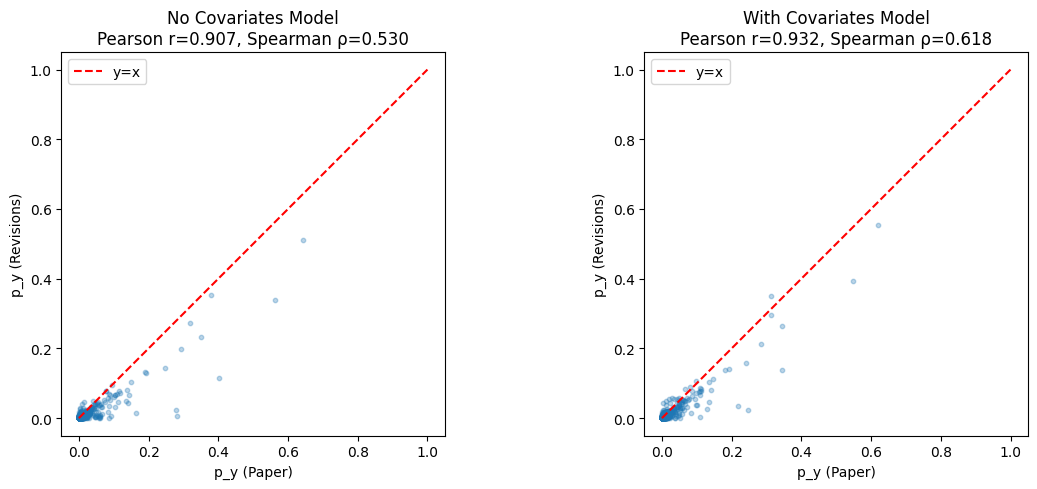

In [11]:
# Create scatter plots comparing results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# No covariates scatter
ax = axes[0]
ax.scatter(merged_nocov['p_y_paper'], merged_nocov['p_y_revisions'], alpha=0.3, s=10)
ax.plot([0, 1], [0, 1], 'r--', label='y=x')
ax.set_xlabel('p_y (Paper)')
ax.set_ylabel('p_y (Revisions)')
ax.set_title(f'No Covariates Model\nPearson r={pearson_nocov:.3f}, Spearman ρ={spearman_nocov:.3f}')
ax.legend()
ax.set_aspect('equal')

# With covariates scatter
ax = axes[1]
ax.scatter(merged_cov['p_y_paper'], merged_cov['p_y_revisions'], alpha=0.3, s=10)
ax.plot([0, 1], [0, 1], 'r--', label='y=x')
ax.set_xlabel('p_y (Paper)')
ax.set_ylabel('p_y (Revisions)')
ax.set_title(f'With Covariates Model\nPearson r={pearson_cov:.3f}, Spearman ρ={spearman_cov:.3f}')
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


In [12]:
# Summary statistics on differences
merged_nocov['diff'] = merged_nocov['p_y_revisions'] - merged_nocov['p_y_paper']
merged_cov['diff'] = merged_cov['p_y_revisions'] - merged_cov['p_y_paper']

print("Difference (Revisions - Paper) Statistics:")
print()
print("NO COVARIATES:")
print(merged_nocov['diff'].describe())
print()
print("WITH COVARIATES:")
print(merged_cov['diff'].describe())


Difference (Revisions - Paper) Statistics:

NO COVARIATES:
count    2325.000000
mean       -0.002737
std         0.014389
min        -0.286452
25%        -0.001813
50%        -0.000696
75%         0.000099
max         0.033197
Name: diff, dtype: float64

WITH COVARIATES:
count    2325.000000
mean       -0.001808
std         0.011003
min        -0.224720
25%        -0.001415
50%        -0.000496
75%         0.000243
max         0.041357
Name: diff, dtype: float64


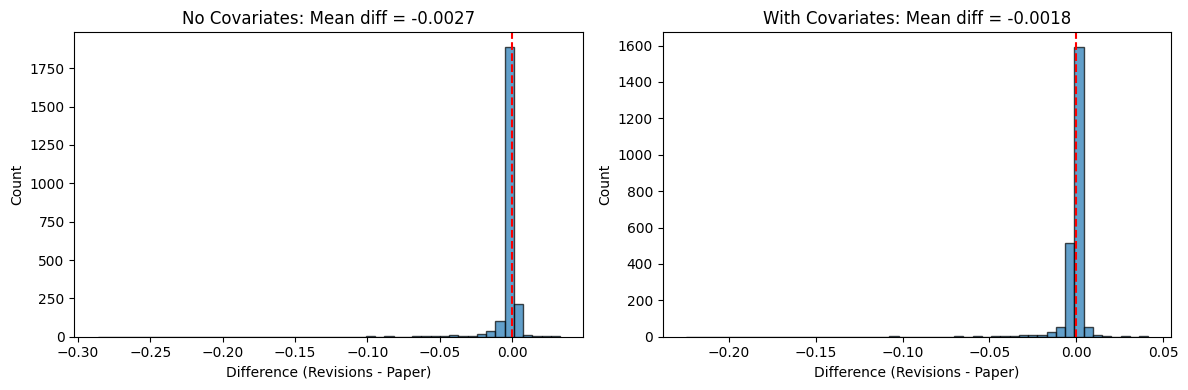

In [13]:
# Histogram of differences
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(merged_nocov['diff'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--')
ax.set_xlabel('Difference (Revisions - Paper)')
ax.set_ylabel('Count')
ax.set_title(f'No Covariates: Mean diff = {merged_nocov["diff"].mean():.4f}')

ax = axes[1]
ax.hist(merged_cov['diff'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--')
ax.set_xlabel('Difference (Revisions - Paper)')
ax.set_ylabel('Count')
ax.set_title(f'With Covariates: Mean diff = {merged_cov["diff"].mean():.4f}')

plt.tight_layout()
plt.show()


In [14]:
# Check rank correlation - are the same tracts ranked similarly?
merged_nocov['rank_revisions'] = merged_nocov['p_y_revisions'].rank()
merged_nocov['rank_paper'] = merged_nocov['p_y_paper'].rank()
merged_nocov['rank_diff'] = merged_nocov['rank_revisions'] - merged_nocov['rank_paper']

merged_cov['rank_revisions'] = merged_cov['p_y_revisions'].rank()
merged_cov['rank_paper'] = merged_cov['p_y_paper'].rank()
merged_cov['rank_diff'] = merged_cov['rank_revisions'] - merged_cov['rank_paper']

print("Rank Difference Statistics (how much did tract rankings change?):")
print()
print("NO COVARIATES:")
print(merged_nocov['rank_diff'].describe())
print()
print("WITH COVARIATES:")
print(merged_cov['rank_diff'].describe())


Rank Difference Statistics (how much did tract rankings change?):

NO COVARIATES:
count    2325.000000
mean        0.000000
std       650.865956
min     -2047.000000
25%      -400.000000
50%         3.000000
75%       373.000000
max      1961.000000
Name: rank_diff, dtype: float64

WITH COVARIATES:
count    2325.000000
mean        0.000000
std       586.882903
min     -2050.000000
25%      -354.000000
50%        -6.000000
75%       326.000000
max      1824.000000
Name: rank_diff, dtype: float64


In [15]:
# Look at tracts with largest changes
print("Top 10 tracts with largest p_y increase (Revisions vs Paper) - NO COVARIATES:")
print(merged_nocov.nlargest(10, 'diff')[[ID_COL, 'p_y_paper', 'p_y_revisions', 'diff']])
print()
print("Top 10 tracts with largest p_y decrease (Revisions vs Paper) - NO COVARIATES:")
print(merged_nocov.nsmallest(10, 'diff')[[ID_COL, 'p_y_paper', 'p_y_revisions', 'diff']])


Top 10 tracts with largest p_y increase (Revisions vs Paper) - NO COVARIATES:
      BoroCT2020  p_y_paper  p_y_revisions      diff
1198     3041500   0.007926       0.041123  0.033197
1119     3030200   0.016104       0.045416  0.029312
396      4025401   0.003206       0.029763  0.026557
1627     4047200   0.004697       0.027058  0.022361
1080     3025500   0.011323       0.027994  0.016671
1604     5011204   0.003654       0.018463  0.014809
1778     4050201   0.005496       0.020239  0.014743
71       1015101   0.001741       0.016259  0.014517
1723     4063301   0.006682       0.020358  0.013676
893      5004001   0.003001       0.015130  0.012129

Top 10 tracts with largest p_y decrease (Revisions vs Paper) - NO COVARIATES:
      BoroCT2020  p_y_paper  p_y_revisions      diff
2258     4097202   0.402486       0.116034 -0.286452
1344     3070203   0.281372       0.005766 -0.275607
1129     3031402   0.278708       0.024083 -0.254625
1144     3034200   0.562272       0.339952 -0.22